# Régression Linéaire Simple et Multiple et La Régression Logistique

#  ❖ Régression Linéaire Simple

Question 1 : 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

Question 2 : 

In [15]:

df = pd.read_csv('Salary_Data.csv')
print(df.head(5))

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


Question 3 :

In [16]:
X = df[['YearsExperience']]
y = df[['Salary']]


Question 4 :

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=40 )

Question 5 :

In [18]:
regressor = LinearRegression()

Question 6 :

In [19]:
regressor.fit(X_train , y_train )
y_pred = regressor.predict(X_test)
print (y_pred)
print(y_pred.shape)

[[41434.13316677]
 [74801.31604849]
 [83143.11176892]
 [69240.11890153]
 [72947.58366617]
 [65532.6541369 ]]
(6, 1)


Question 7 :

In [20]:
print(regressor.predict([[15]]))
print(regressor.coef_)

[[166561.06897321]]
[[9268.66191159]]


c:\Users\ilyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Question 8 :

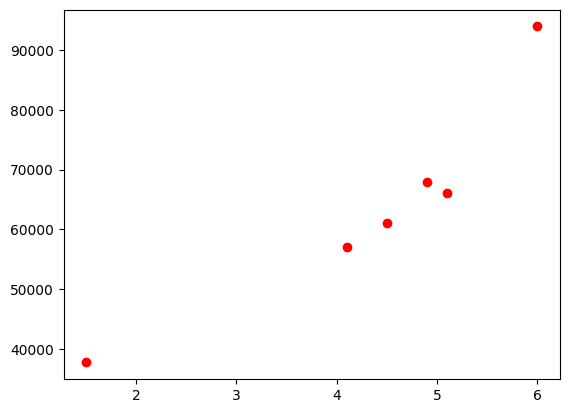

In [21]:
plt.scatter(X_test , y_test , c = 'r' )
#plt.plot(X_test, y_pred, c='r')

Question 9 :

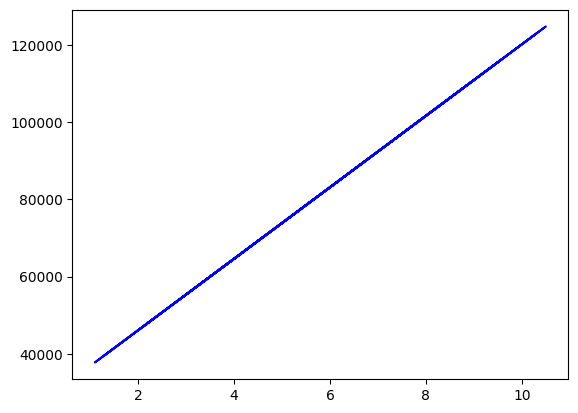

In [22]:
plt.plot(X_train , regressor.predict(X_train) , c = 'b' )


Question 10:

- Les points rouges (test) sont proches de la droite bleue → le modèle généralise bien.
- La relation est quasi-linéaire entre expérience et salaire.


Question 11 :

In [23]:
a = float(regressor.coef_[0])
b = float(regressor.intercept_)
print(f"Coefficient a (pente)     : {a:.2f}")
print(f"Intercept  b              : {b:.2f}")
print(f"Équation : y = {a:.2f}x + {b:.2f}")

Coefficient a (pente)     : 9268.66
Intercept  b              : 27531.14
Équation : y = 9268.66x + 27531.14


C:\Users\ilyas\AppData\Local\Temp\ipykernel_1480\2302395927.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a = float(regressor.coef_[0])
C:\Users\ilyas\AppData\Local\Temp\ipykernel_1480\2302395927.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b = float(regressor.intercept_)


Question 12 :

In [24]:
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.7775
MSE      : 61641413.31
RMSE     : 7851.20


Question 13 :

In [25]:
print(f"Min de y : {y.min()}")
print(f"Max de y : {y.max()}")

Min de y : Salary    37731.0
dtype: float64
Max de y : Salary    122391.0
dtype: float64


# patie 2 :

# ❖Régression Linéaire Multiple

Question 1 : 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE

Question 2 :

In [27]:
dataset = pd.read_csv('50_Startups.csv')
print(dataset.head())
print(dataset.shape)

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
(50, 5)


Question 3 :

In [28]:
X = dataset.iloc[:, :-1].values 
y = dataset.iloc[:, -1].values

Question 4:

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [3])],  # colonne 3 = State
    remainder='passthrough'
)
X = np.array(ct.fit_transform(X))
X = X[:, 1:]

print("Shape de X après encodage :", X.shape)

Shape de X après encodage : (50, 5)


Question 5 :

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40, 5)
X_test shape: (10, 5)
y_train shape: (40,)
y_test shape: (10,)


In [31]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = regressor.predict(X_test)
print("\nComparaison y_pred vs y_test :")
print(np.concatenate((y_pred.reshape(-1,1), y_test.reshape(-1,1)), axis=1))


Comparaison y_pred vs y_test :
[[103015.20159796 103282.38      ]
 [132582.27760816 144259.4       ]
 [132447.73845175 146121.95      ]
 [ 71976.09851259  77798.83      ]
 [178537.48221054 191050.39      ]
 [116161.24230163 105008.31      ]
 [ 67851.69209676  81229.06      ]
 [ 98791.73374688  97483.56      ]
 [113969.43533012 110352.25      ]
 [167921.0656955  166187.94      ]]


In [33]:
# Pour ce modèle, X a 5 features après suppression de la colonne dummy de référence
# Exemple État=California -> dummies [0, 0] (car colonne 0 supprimée)
prediction = regressor.predict(np.array([[0, 0, 130000, 140000, 300000]]))
print(f"\nPrédiction profit : {prediction[0]:.2f} $")



Prédiction profit : 158691.75 $


In [34]:
print(f"\nIntercept : {regressor.intercept_:.2f}")
print(f"Coefficients : {regressor.coef_}")



Intercept : 42554.17
Coefficients : [-9.59284160e+02  6.99369053e+02  7.73467193e-01  3.28845975e-02
  3.66100259e-02]


In [35]:
r2 = r2_score(y_test, y_pred)
print(f"\nR² Score : {r2:.4f}")



R² Score : 0.9347


In [36]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(X_train, y_train)

print("\nVariables sélectionnées par RFE :", rfe.support_)
print("Ranking des variables            :", rfe.ranking_)


X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

regressor_rfe = LinearRegression()
regressor_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = regressor_rfe.predict(X_test_rfe)
r2_rfe = r2_score(y_test, y_pred_rfe)
print(f"R² Score après RFE (3 variables) : {r2_rfe:.4f}")


Variables sélectionnées par RFE : [ True  True  True False False]
Ranking des variables            : [1 1 1 3 2]
R² Score après RFE (3 variables) : 0.9472
